In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SRC = Path("..") / "src"
sys.path.insert(0, str(SRC))

import synthetic_cfd_stage1_soret as scs1s
import pinn_inverse_diffusion_soret as pids
from plot_utils import apply_plot_style, MU_SB, DEG_SB
from json_utils import json_convert, json_deconvert

apply_plot_style()

np.random.seed(0)

In [3]:
RESULTS_DIR = Path("..") / "results" / "stage1_soret_diffusion_demo"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path("..") / "data" / "processed"
DATASET_SOURCE_PATH = DATA_DIR / "stage1_soret_synthetic_dataset.npz"

DATASET_CHECK_PATH = RESULTS_DIR / "dataset_check.json"
CHECKPOINT_PATH = RESULTS_DIR / "main_run_checkpoint.pt"
HISTORY_PATH = RESULTS_DIR / "main_run_history.json"
NOISE_SWEEP_PATH = RESULTS_DIR / "noise_sweep.json"
SPARSITY_SWEEP_PATH = RESULTS_DIR / "sparsity_sweep.json"

FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FORCE_RETRAIN = False
RESUME_TRAINING = True

## Fake CFD: Stokes' first problem (Soret-coupled)

In [4]:
RHO = 1.0
ALPHA_KNOWN = 0.12
MU_TRUE = 0.08
D_TRUE = 0.03
DT_TRUE = 0.015
U0_TRUE = 1.0
TW = 1.0
YW = 1.0
NOISE_STD = 0.0

X_RANGE = (0.0, 1.0)
Y_RANGE = (0.0, 1.0)
Z_RANGE = (0.0, 2.5)
T_RANGE = (0.1, 1.0)

dataset = scs1s.sample_synthetic_stage1_soret_dataset(
    n_samples=3000,
    mu=MU_TRUE,
    D=D_TRUE,
    D_T=DT_TRUE,
    alpha=ALPHA_KNOWN,
    U0=U0_TRUE,
    rho=RHO,
    Tw=TW,
    Yw=YW,
    x_range=X_RANGE,
    y_range=Y_RANGE,
    z_range=Z_RANGE,
    t_range=T_RANGE,
    noise_std=NOISE_STD,
    seed=0,
)
scs1s.save_dataset(dataset, DATASET_SOURCE_PATH)

print({k: (v.shape if hasattr(v, "shape") else v) for k, v in dataset.items()})

{'X': (3000, 4), 'u': (3000, 1), 'v': (3000, 1), 'w': (3000, 1), 'p': (3000, 1), 'T': (3000, 1), 'Y': (3000, 1), 'mu_true': 0.08, 'D_true': 0.03, 'DT_true': 0.015, 'alpha': 0.12, 'U0_true': 1.0, 'rho': 1.0, 'Tw': 1.0, 'Yw': 1.0}


### Plot/Check

In [11]:
CHECK_T_SNAPSHOTS = [0.1, 0.4, 0.7, 1.0]
CHECK_T_TOL = 0.03

if DATASET_CHECK_PATH.exists() and not FORCE_RETRAIN:
    print(f"Found saved dataset check data, skipping recomputation: {DATASET_CHECK_PATH}")
else:
    z_lin = np.linspace(Z_RANGE[0], Z_RANGE[1], 200)

    exact_u, exact_T, exact_Y = [], [], []
    sample_z, sample_u, sample_T, sample_Y = [], [], [], []
    X_all = dataset["X"]
    z_all, t_all = X_all[:, 2], X_all[:, 3]

    for t_snap in CHECK_T_SNAPSHOTS:
        u_line, _, _, _ = scs1s.velocity_field(z_lin, t_snap, U0_TRUE, MU_TRUE, RHO)
        T_line = scs1s.temperature_field(z_lin, t_snap, ALPHA_KNOWN, TW)
        Y_line = scs1s.species_field(z_lin, t_snap, D_TRUE, DT_TRUE, ALPHA_KNOWN, RHO, YW, TW)
        exact_u.append(u_line)
        exact_T.append(T_line)
        exact_Y.append(Y_line)

        mask = np.abs(t_all - t_snap) <= CHECK_T_TOL
        sample_z.append(z_all[mask])
        sample_u.append(dataset["u"][mask, 0])
        sample_T.append(dataset["T"][mask, 0])
        sample_Y.append(dataset["Y"][mask, 0])

    check_data = {
        "z_lin": z_lin,
        "t_snapshots": CHECK_T_SNAPSHOTS,
        "exact_u": exact_u, "exact_T": exact_T, "exact_Y": exact_Y,
        "sample_z": sample_z, "sample_u": sample_u, "sample_T": sample_T, "sample_Y": sample_Y,
    }
    with open(DATASET_CHECK_PATH, "w", encoding="utf-8") as f:
        json.dump(check_data, f, default=json_convert, ensure_ascii=False, indent=2)
    print(f"Dataset check data saved to: {DATASET_CHECK_PATH}")

Found saved dataset check data, skipping recomputation: ..\results\stage1_soret_diffusion_demo\dataset_check.json


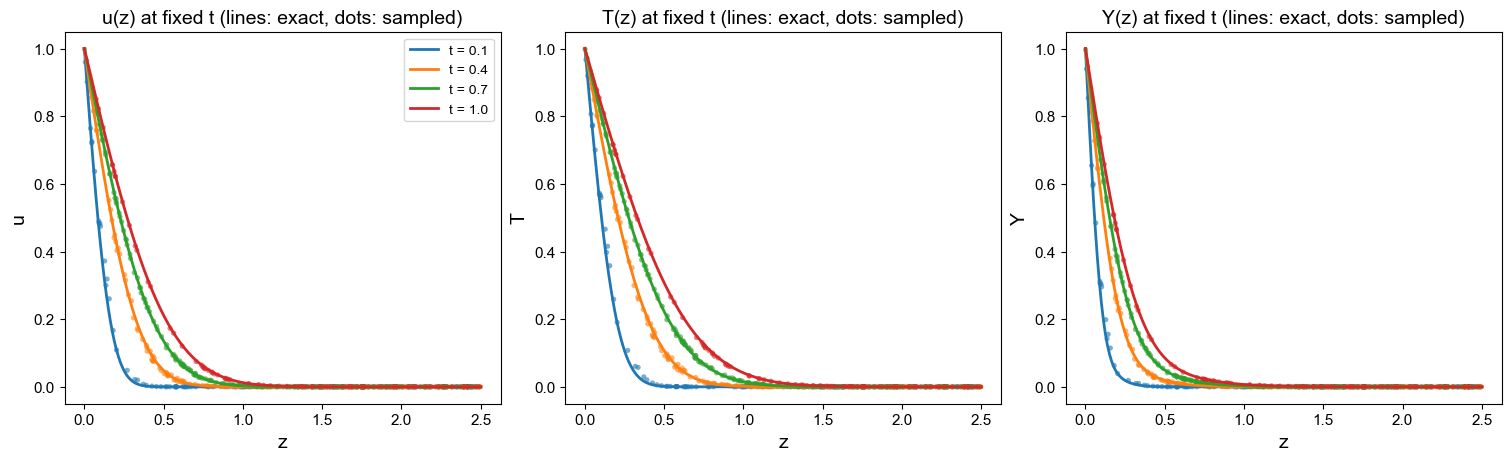

In [12]:
with open(DATASET_CHECK_PATH, encoding="utf-8") as f:
    check_data = json.load(f, object_hook=json_deconvert)

z_lin = check_data["z_lin"]
t_snapshots = check_data["t_snapshots"]
colors = [f"C{i}" for i in range(len(t_snapshots))]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
field_names = ["u", "T", "Y"]
for ax, name in zip(axes, field_names):
    for i, t_snap in enumerate(t_snapshots):
        ax.plot(z_lin, check_data[f"exact_{name}"][i], color=colors[i], label=f"t = {t_snap}")
        ax.scatter(
            check_data["sample_z"][i], check_data[f"sample_{name}"][i],
            color=colors[i], s=14, alpha=0.6, edgecolors="none",
        )
    ax.set_xlabel("z"); ax.set_ylabel(name)
    ax.set_title(f"{name}(z) at fixed t (lines: exact, dots: sampled)")
axes[0].legend(fontsize=10)

fig.savefig(FIGURES_DIR / "dataset_check.png", dpi=150)
plt.show()

## Train PINN, inverse mu/D/DT

In [13]:
MU_INIT = 1.0
D_INIT = 1.0
DT_INIT = 1.0

result = pids.run_inverse_soret_diffusion(
    dataset,
    rho=RHO,
    alpha=ALPHA_KNOWN,
    mu_init=MU_INIT,
    D_init=D_INIT,
    DT_init=DT_INIT,
    source_fn=None,
    x_range=X_RANGE,
    y_range=Y_RANGE,
    z_range=Z_RANGE,
    t_range=T_RANGE,
    num_domain=4000,
    adam_iterations=15000,
    adam_lr=1e-3,
    log_every=500,
    checkpoint_path=CHECKPOINT_PATH,
    resume=RESUME_TRAINING,
)

with open(HISTORY_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "history": result["history"],
            "mu_recovered": result["mu_recovered"], "mu_true": MU_TRUE,
            "D_recovered": result["D_recovered"], "D_true": D_TRUE,
            "DT_recovered": result["DT_recovered"], "DT_true": DT_TRUE,
        },
        f, default=json_convert, ensure_ascii=False, indent=2,
    )

print(f"mu_true={MU_TRUE}  mu_recovered={result['mu_recovered']:.5f}")
print(f"D_true ={D_TRUE}  D_recovered ={result['D_recovered']:.5f}")
print(f"DT_true={DT_TRUE}  DT_recovered={result['DT_recovered']:.5f}")

Training on device: cuda
[adam] iter      0  loss=1.3003e+00  data=9.2150e-01  pde=3.7879e-01  mu=0.99900  D=0.99900  DT=0.99900
[adam] iter    500  loss=3.1797e-02  data=2.8918e-02  pde=2.8797e-03  mu=0.80175  D=0.61338  DT=0.54448
[adam] iter   1000  loss=1.0416e-02  data=9.7893e-03  pde=6.2669e-04  mu=0.43349  D=0.06388  DT=0.08262
[adam] iter   1500  loss=2.5881e-03  data=2.3388e-03  pde=2.4936e-04  mu=0.08874  D=0.01140  DT=0.05150
[adam] iter   2000  loss=1.5437e-03  data=1.2997e-03  pde=2.4399e-04  mu=0.07404  D=0.01491  DT=0.04495
[adam] iter   2500  loss=1.2650e-03  data=1.0188e-03  pde=2.4617e-04  mu=0.07160  D=0.01390  DT=0.04622
[adam] iter   3000  loss=7.4810e-04  data=5.6277e-04  pde=1.8533e-04  mu=0.07166  D=0.01655  DT=0.04117
[adam] iter   3500  loss=5.5460e-04  data=4.0472e-04  pde=1.4988e-04  mu=0.07243  D=0.01976  DT=0.03433
[adam] iter   4000  loss=7.1746e-04  data=3.8521e-04  pde=3.3225e-04  mu=0.07257  D=0.02149  DT=0.03083
[adam] iter   4500  loss=3.6712e-04  da

### Loss, mu/D/DT convergence

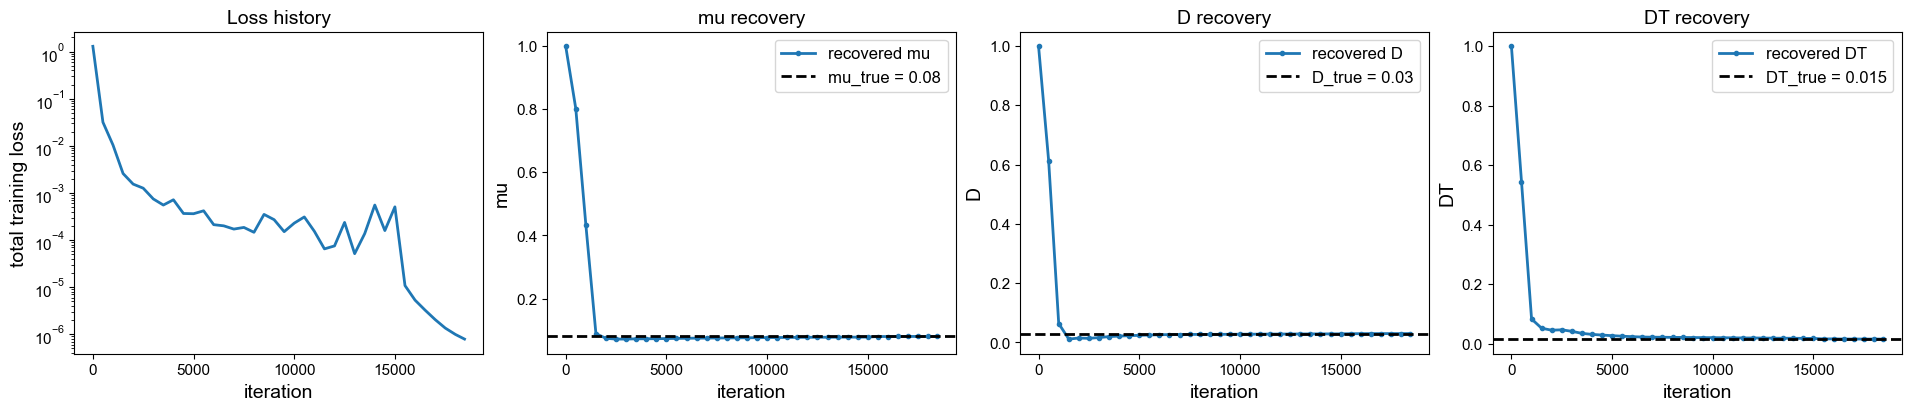

In [14]:
with open(HISTORY_PATH, encoding="utf-8") as f:
    history_data = json.load(f, object_hook=json_deconvert)
history = history_data["history"]

fig, axes = plt.subplots(1, 4, figsize=(19, 4), constrained_layout=True)

axes[0].semilogy(history["iteration"], history["loss"])
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("total training loss"); axes[0].set_title("Loss history")

for ax, name, true_key in zip(axes[1:], ["mu", "D", "DT"], ["mu_true", "D_true", "DT_true"]):
    true_val = history_data[true_key]
    ax.plot(history["iteration"], history[name], marker="o", ms=3, label=f"recovered {name}")
    ax.axhline(true_val, color="k", ls="--", label=f"{name}_true = {true_val}")
    ax.set_xlabel("iteration"); ax.set_ylabel(name); ax.set_title(f"{name} recovery"); ax.legend()

fig.savefig(FIGURES_DIR / "loss_mu_D_DT_convergence.png", dpi=150)
plt.show()

### Reconstruct

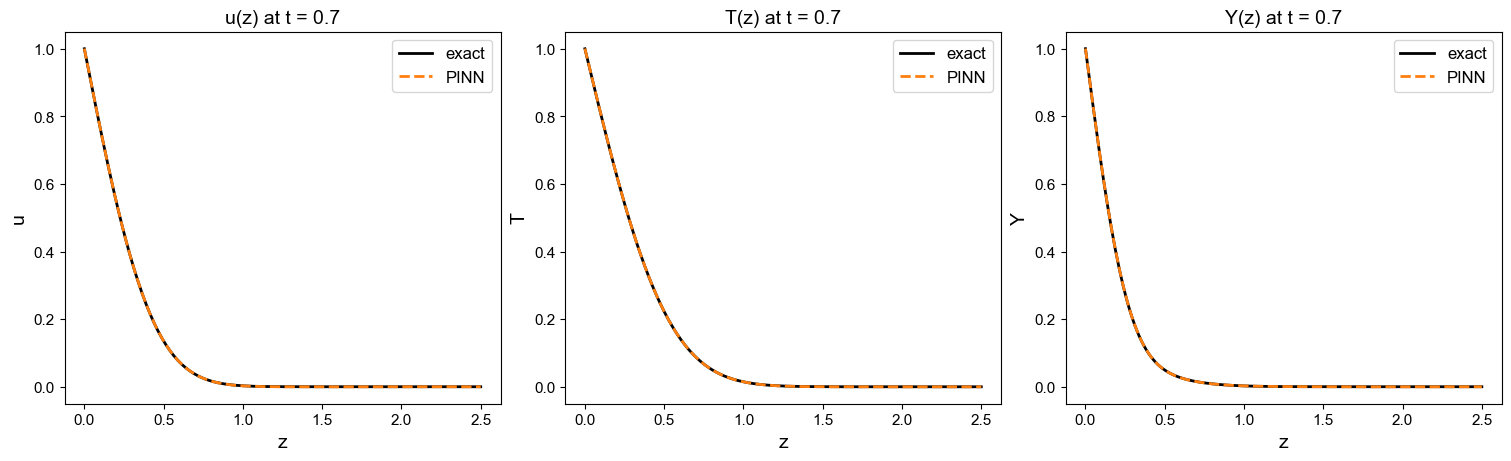

mu_recovered=0.07994  D_recovered=0.02996  DT_recovered=0.01505


In [15]:
with open(DATASET_CHECK_PATH, encoding="utf-8") as f:
    check_data = json.load(f, object_hook=json_deconvert)

t_snap = 0.7
snap_idx = check_data["t_snapshots"].index(t_snap)
z_lin = check_data["z_lin"]

model, mu_recovered, D_recovered, DT_recovered = pids.load_model(CHECKPOINT_PATH)
grid_X = np.column_stack([
    np.zeros_like(z_lin), np.zeros_like(z_lin), z_lin, np.full_like(z_lin, t_snap),
])
pred = model.predict(grid_X)
u_pred, T_pred, Y_pred = pred[:, 0], pred[:, 4], pred[:, 5]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
field_names = ["u", "T", "Y"]
exact_lines = [check_data["exact_u"][snap_idx], check_data["exact_T"][snap_idx], check_data["exact_Y"][snap_idx]]
pred_lines = [u_pred, T_pred, Y_pred]
for ax, name, exact_line, pred_line in zip(axes, field_names, exact_lines, pred_lines):
    ax.plot(z_lin, exact_line, "k-", label="exact")
    ax.plot(z_lin, pred_line, "C1--", label="PINN")
    ax.set_xlabel("z"); ax.set_ylabel(name); ax.set_title(f"{name}(z) at t = {t_snap}"); ax.legend()

fig.savefig(FIGURES_DIR / "field_reconstruction.png", dpi=150)
plt.show()

print(f"mu_recovered={mu_recovered:.5f}  D_recovered={D_recovered:.5f}  DT_recovered={DT_recovered:.5f}")

## Noise sensitivity

In [16]:
import contextlib
import io


def run_one(n_samples, noise_std, seed, adam_iterations, lbfgs_iterations):
    ds = scs1s.sample_synthetic_stage1_soret_dataset(
        n_samples=n_samples,
        mu=MU_TRUE, D=D_TRUE, D_T=DT_TRUE, alpha=ALPHA_KNOWN, U0=U0_TRUE, rho=RHO,
        Tw=TW, Yw=YW,
        x_range=X_RANGE, y_range=Y_RANGE, z_range=Z_RANGE, t_range=T_RANGE,
        noise_std=noise_std, seed=seed,
    )
    with contextlib.redirect_stdout(io.StringIO()):
        result = pids.run_inverse_soret_diffusion(
            ds,
            rho=RHO, alpha=ALPHA_KNOWN,
            mu_init=MU_INIT, D_init=D_INIT, DT_init=DT_INIT,
            x_range=X_RANGE, y_range=Y_RANGE, z_range=Z_RANGE, t_range=T_RANGE,
            num_domain=4000,
            adam_iterations=adam_iterations, adam_lr=1e-3, log_every=adam_iterations,
            run_lbfgs=True, lbfgs_iterations=lbfgs_iterations,
            seed=seed,
        )
    recovered = {"mu": result["mu_recovered"], "D": result["D_recovered"], "DT": result["DT_recovered"]}
    true_vals = {"mu": MU_TRUE, "D": D_TRUE, "DT": DT_TRUE}
    rel_error = {k: abs(recovered[k] - true_vals[k]) / true_vals[k] for k in recovered}
    return recovered, rel_error


def run_sweep(param_name, param_values, n_repeats, **fixed_kwargs):
    records = {"param": [], "seed": []}
    for name in ["mu", "D", "DT"]:
        records[f"{name}_recovered"] = []
        records[f"{name}_rel_error"] = []
    for value in param_values:
        for seed in range(n_repeats):
            kwargs = dict(fixed_kwargs)
            kwargs[param_name] = value
            recovered, rel_error = run_one(seed=seed, **kwargs)
            records["param"].append(value)
            records["seed"].append(seed)
            for name in ["mu", "D", "DT"]:
                records[f"{name}_recovered"].append(recovered[name])
                records[f"{name}_rel_error"].append(rel_error[name])
            print(
                f"{param_name}={value!r:>8}  seed={seed}  "
                + "  ".join(f"{name}_rel_error={rel_error[name]:.2%}" for name in ["mu", "D", "DT"])
            )
    return {k: np.array(v) for k, v in records.items()}


def summarize_sweep(records, param_values):
    summary = {}
    for name in ["mu", "D", "DT"]:
        means, stds, rel_means, rel_stds = [], [], [], []
        for value in param_values:
            mask = records["param"] == value
            means.append(records[f"{name}_recovered"][mask].mean())
            stds.append(records[f"{name}_recovered"][mask].std())
            rel_means.append(records[f"{name}_rel_error"][mask].mean())
            rel_stds.append(records[f"{name}_rel_error"][mask].std())
        summary[name] = tuple(np.array(a) for a in (means, stds, rel_means, rel_stds))
    return summary

In [17]:
NOISE_LEVELS = [0.0, 0.01, 0.05, 0.1]
N_REPEATS = 3
SWEEP_ADAM_ITERS = 6000
SWEEP_LBFGS_ITERS = 5000

if NOISE_SWEEP_PATH.exists() and not FORCE_RETRAIN:
    print(f"Found saved noise sweep results, skipping retraining: {NOISE_SWEEP_PATH}")
else:
    noise_records = run_sweep(
        "noise_std",
        NOISE_LEVELS,
        n_repeats=N_REPEATS,
        n_samples=3000,
        adam_iterations=SWEEP_ADAM_ITERS,
        lbfgs_iterations=SWEEP_LBFGS_ITERS,
    )
    with open(NOISE_SWEEP_PATH, "w", encoding="utf-8") as f:
        json.dump(
            {"records": noise_records, "mu_true": MU_TRUE, "D_true": D_TRUE, "DT_true": DT_TRUE},
            f, default=json_convert, ensure_ascii=False, indent=2,
        )
    print(f"Noise sweep results saved to: {NOISE_SWEEP_PATH}")

noise_std=     0.0  seed=0  mu_rel_error=0.02%  D_rel_error=0.00%  DT_rel_error=0.15%
noise_std=     0.0  seed=1  mu_rel_error=0.06%  D_rel_error=0.15%  DT_rel_error=0.17%
noise_std=     0.0  seed=2  mu_rel_error=0.01%  D_rel_error=0.27%  DT_rel_error=0.63%
noise_std=    0.01  seed=0  mu_rel_error=0.12%  D_rel_error=2.09%  DT_rel_error=6.41%
noise_std=    0.01  seed=1  mu_rel_error=0.03%  D_rel_error=0.54%  DT_rel_error=1.14%
noise_std=    0.01  seed=2  mu_rel_error=0.39%  D_rel_error=0.02%  DT_rel_error=1.07%
noise_std=    0.05  seed=0  mu_rel_error=0.90%  D_rel_error=12.21%  DT_rel_error=32.96%
noise_std=    0.05  seed=1  mu_rel_error=1.03%  D_rel_error=3.21%  DT_rel_error=5.47%
noise_std=    0.05  seed=2  mu_rel_error=0.37%  D_rel_error=2.20%  DT_rel_error=9.95%
noise_std=     0.1  seed=0  mu_rel_error=8.34%  D_rel_error=28.77%  DT_rel_error=81.15%
noise_std=     0.1  seed=1  mu_rel_error=3.07%  D_rel_error=6.12%  DT_rel_error=10.42%
noise_std=     0.1  seed=2  mu_rel_error=0.65%  D

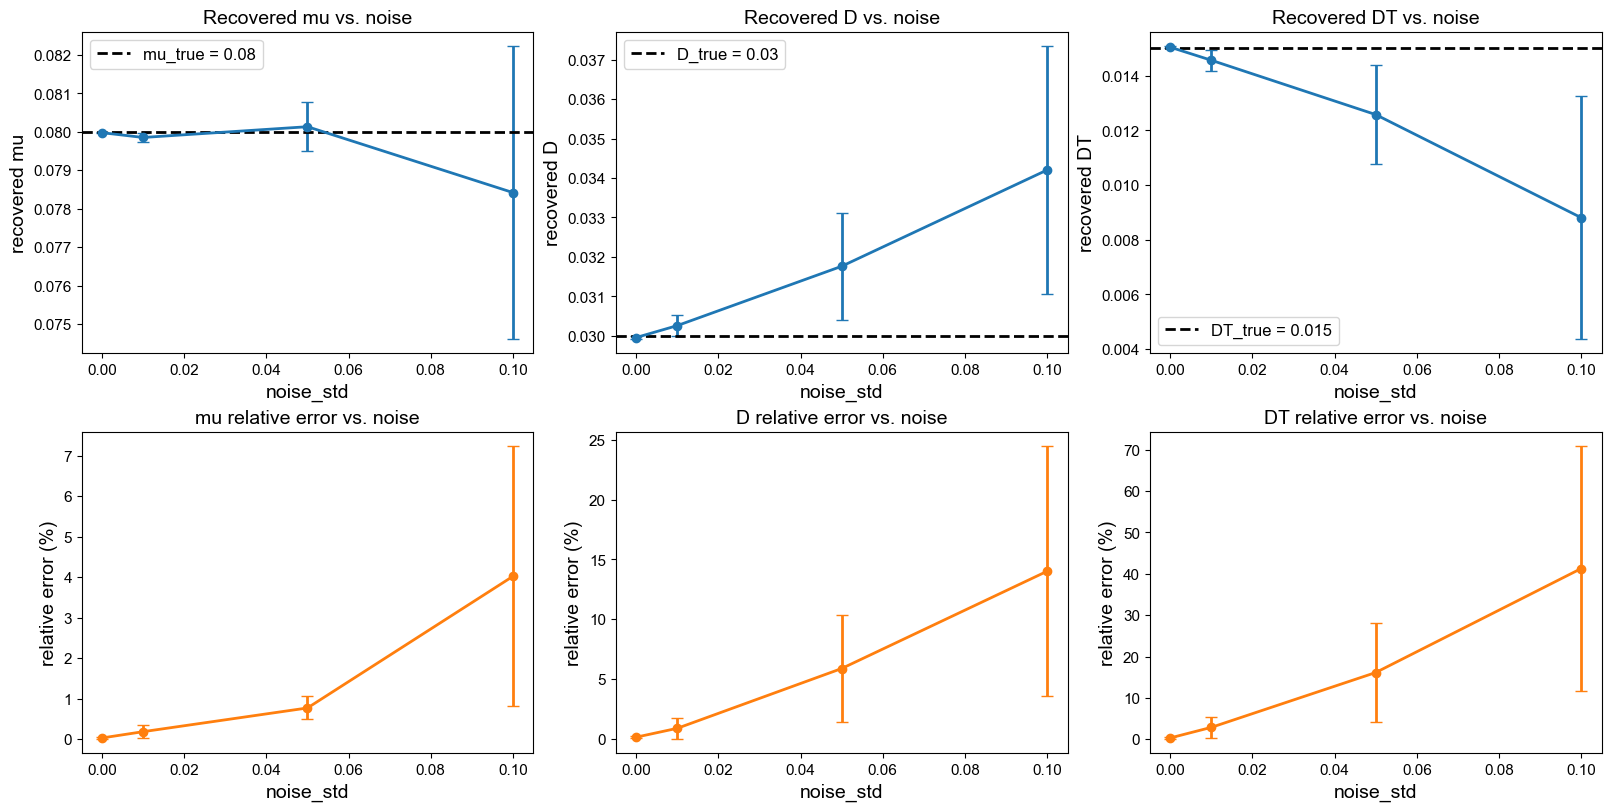

In [18]:
with open(NOISE_SWEEP_PATH, encoding="utf-8") as f:
    noise_data = json.load(f, object_hook=json_deconvert)
noise_records = noise_data["records"]
noise_levels = sorted(set(noise_records["param"].tolist()))
true_vals = {"mu": noise_data["mu_true"], "D": noise_data["D_true"], "DT": noise_data["DT_true"]}

summary = summarize_sweep(noise_records, noise_levels)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for col, name in enumerate(["mu", "D", "DT"]):
    mean, std, rel_mean, rel_std = summary[name]
    ax_top, ax_bot = axes[0, col], axes[1, col]

    ax_top.errorbar(noise_levels, mean, yerr=std, marker="o", capsize=4)
    ax_top.axhline(true_vals[name], color="k", ls="--", label=f"{name}_true = {true_vals[name]}")
    ax_top.set_xlabel("noise_std"); ax_top.set_ylabel(f"recovered {name}")
    ax_top.set_title(f"Recovered {name} vs. noise"); ax_top.legend()

    ax_bot.errorbar(noise_levels, rel_mean * 100, yerr=rel_std * 100, marker="o", capsize=4, color="C1")
    ax_bot.set_xlabel("noise_std"); ax_bot.set_ylabel("relative error (%)")
    ax_bot.set_title(f"{name} relative error vs. noise")

fig.savefig(FIGURES_DIR / "noise_sweep.png", dpi=150)
plt.show()

### Scaling analysis

Momentum:
$$\rho \frac{\partial u}{\partial t} - \mu \frac{\partial^2 u}{\partial z^2} = 0$$

Energy:
$$\frac{\partial T}{\partial t} - \alpha \frac{\partial^2 T}{\partial z^2} = 0$$

Species:
$$\rho \frac{\partial Y}{\partial t} - D \frac{\partial^2 Y}{\partial z^2} - D_T \frac{\partial^2 T}{\partial z^2} = 0$$

Solution:

$$u(z,t) = U_0 \,\mathrm{erfc}\!\left(\frac{z}{2\sqrt{(\mu/\rho)\,t}}\right)$$

$$T(z,t) = T_w \,\mathrm{erfc}\!\left(\frac{z}{2\sqrt{\alpha\, t}}\right)$$

$$Y(z,t) = K \,\mathrm{erfc}\!\left(\frac{z}{2\sqrt{(D/\rho)\,t}}\right) - C \,\mathrm{erfc}\!\left(\frac{z}{2\sqrt{\alpha\, t}}\right),
\qquad C = \frac{D_T T_w}{D - \rho\alpha},\quad K = Y_w + C$$

In [5]:
import sympy as sp

z_sym, t_sym = sp.symbols("z t", positive=True)

u_sym = U0_TRUE * sp.erfc(z_sym / (2 * sp.sqrt((MU_TRUE / RHO) * t_sym)))
T_sym = TW * sp.erfc(z_sym / (2 * sp.sqrt(ALPHA_KNOWN * t_sym)))
C_sym = DT_TRUE * TW / (D_TRUE - RHO * ALPHA_KNOWN)
K_sym = YW + C_sym
Y_sym = K_sym * sp.erfc(z_sym / (2 * sp.sqrt((D_TRUE / RHO) * t_sym))) - C_sym * sp.erfc(
    z_sym / (2 * sp.sqrt(ALPHA_KNOWN * t_sym))
)

u_zz_fn = sp.lambdify((z_sym, t_sym), sp.diff(u_sym, z_sym, 2), "numpy")
T_zz_fn = sp.lambdify((z_sym, t_sym), sp.diff(T_sym, z_sym, 2), "numpy")
Y_zz_fn = sp.lambdify((z_sym, t_sym), sp.diff(Y_sym, z_sym, 2), "numpy")

rng_scaling = np.random.default_rng(0)
z_scaling = rng_scaling.uniform(*Z_RANGE, 3000)
t_scaling = rng_scaling.uniform(*T_RANGE, 3000)

mu_term_mag = np.mean(np.abs(MU_TRUE * u_zz_fn(z_scaling, t_scaling)))
D_term_mag = np.mean(np.abs(D_TRUE * Y_zz_fn(z_scaling, t_scaling)))
DT_term_mag = np.mean(np.abs(DT_TRUE * T_zz_fn(z_scaling, t_scaling)))

print(f"mean |mu * u_zz| (momentum eq.) = {mu_term_mag:.4e}")
print(f"mean |D * Y_zz|  (species eq.)  = {D_term_mag:.4e}")
print(f"mean |DT * T_zz| (species eq.)  = {DT_term_mag:.4e}")
print(f"scaling ratio mu-term : D-term : DT-term = {mu_term_mag / DT_term_mag:.2f} : {D_term_mag / DT_term_mag:.2f} : 1")

mean |mu * u_zz| (momentum eq.) = 9.9088e-02
mean |D * Y_zz|  (species eq.)  = 5.7210e-02
mean |DT * T_zz| (species eq.)  = 1.5074e-02
scaling ratio mu-term : D-term : DT-term = 6.57 : 3.80 : 1


## Sample number sensitivity

In [19]:
SAMPLE_COUNTS = [3000, 1000, 300, 100, 30]

if SPARSITY_SWEEP_PATH.exists() and not FORCE_RETRAIN:
    print(f"Found saved sparsity sweep results, skipping retraining: {SPARSITY_SWEEP_PATH}")
else:
    sparsity_records = run_sweep(
        "n_samples",
        SAMPLE_COUNTS,
        n_repeats=N_REPEATS,
        noise_std=0.0,
        adam_iterations=SWEEP_ADAM_ITERS,
        lbfgs_iterations=SWEEP_LBFGS_ITERS,
    )
    with open(SPARSITY_SWEEP_PATH, "w", encoding="utf-8") as f:
        json.dump(
            {"records": sparsity_records, "mu_true": MU_TRUE, "D_true": D_TRUE, "DT_true": DT_TRUE},
            f, default=json_convert, ensure_ascii=False, indent=2,
        )
    print(f"Sparsity sweep results saved to: {SPARSITY_SWEEP_PATH}")

n_samples=    3000  seed=0  mu_rel_error=0.02%  D_rel_error=0.00%  DT_rel_error=0.15%
n_samples=    3000  seed=1  mu_rel_error=0.06%  D_rel_error=0.15%  DT_rel_error=0.17%
n_samples=    3000  seed=2  mu_rel_error=0.01%  D_rel_error=0.27%  DT_rel_error=0.63%
n_samples=    1000  seed=0  mu_rel_error=0.08%  D_rel_error=0.21%  DT_rel_error=0.16%
n_samples=    1000  seed=1  mu_rel_error=0.02%  D_rel_error=0.03%  DT_rel_error=0.05%
n_samples=    1000  seed=2  mu_rel_error=0.04%  D_rel_error=0.31%  DT_rel_error=0.48%
n_samples=     300  seed=0  mu_rel_error=0.36%  D_rel_error=0.52%  DT_rel_error=0.03%
n_samples=     300  seed=1  mu_rel_error=0.00%  D_rel_error=0.67%  DT_rel_error=0.96%
n_samples=     300  seed=2  mu_rel_error=0.41%  D_rel_error=0.79%  DT_rel_error=0.07%
n_samples=     100  seed=0  mu_rel_error=1.42%  D_rel_error=0.24%  DT_rel_error=2.38%
n_samples=     100  seed=1  mu_rel_error=0.55%  D_rel_error=1.62%  DT_rel_error=3.93%
n_samples=     100  seed=2  mu_rel_error=0.14%  D_rel_

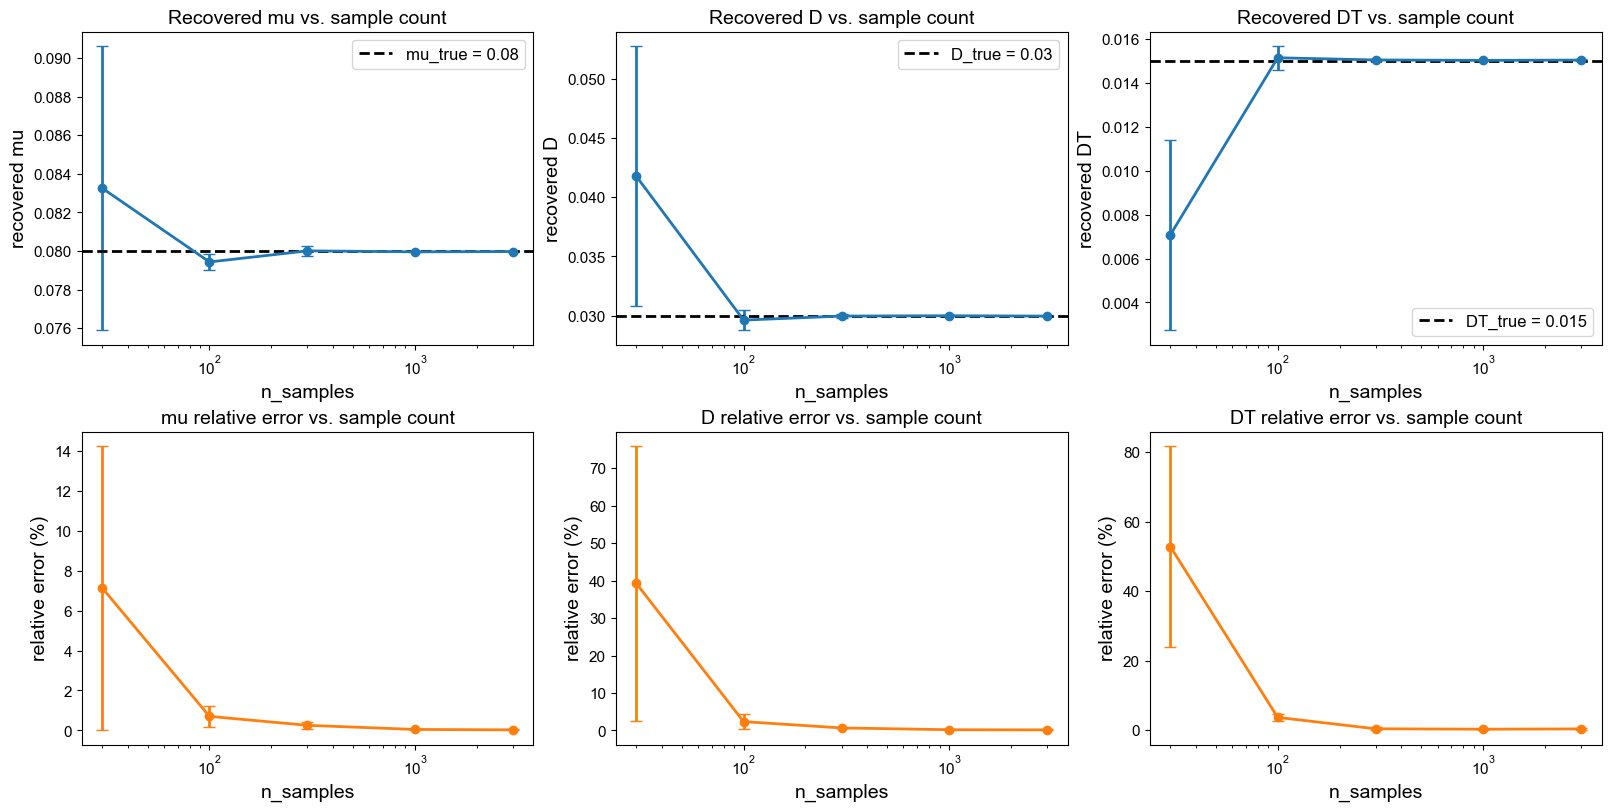

In [20]:
with open(SPARSITY_SWEEP_PATH, encoding="utf-8") as f:
    sparsity_data = json.load(f, object_hook=json_deconvert)
sparsity_records = sparsity_data["records"]
sample_counts = sorted(set(sparsity_records["param"].tolist()))
true_vals = {"mu": sparsity_data["mu_true"], "D": sparsity_data["D_true"], "DT": sparsity_data["DT_true"]}

summary = summarize_sweep(sparsity_records, sample_counts)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for col, name in enumerate(["mu", "D", "DT"]):
    mean, std, rel_mean, rel_std = summary[name]
    ax_top, ax_bot = axes[0, col], axes[1, col]

    ax_top.errorbar(sample_counts, mean, yerr=std, marker="o", capsize=4)
    ax_top.axhline(true_vals[name], color="k", ls="--", label=f"{name}_true = {true_vals[name]}")
    ax_top.set_xscale("log")
    ax_top.set_xlabel("n_samples"); ax_top.set_ylabel(f"recovered {name}")
    ax_top.set_title(f"Recovered {name} vs. sample count"); ax_top.legend()

    ax_bot.errorbar(sample_counts, rel_mean * 100, yerr=rel_std * 100, marker="o", capsize=4, color="C1")
    ax_bot.set_xscale("log")
    ax_bot.set_xlabel("n_samples"); ax_bot.set_ylabel("relative error (%)")
    ax_bot.set_title(f"{name} relative error vs. sample count")

fig.savefig(FIGURES_DIR / "sparsity_sweep.png", dpi=150)
plt.show()